# Continuous Subsequence DTW Shape Alignment & Visualization

This notebook demonstrates and visualizes our **Continuous Subsequence DTW (Dynamic Time Warping)** shape-matching algorithm. 

We will:
1. Define a long, curved **Target Road (Curve A)** and a shorter, parallel **Query Road (Curve B)** representing a divided segment.
2. Execute `dtw_align` to spatially sample and dynamically align the sequences.
3. Use `matplotlib` to plot both roads and draw the **warping path alignment links** showing exactly how the vertices are matched.

In [5]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString

# Ensure our local network_matching library is in the Python path
sys.path.append(os.path.abspath(".."))
from network_matching import dtw_align

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Define Simulated Curved Roads

We simulate a common real-world split geometry:
* **Road A (Target)**: A long, winding road (from $X=0$ to $X=100$, modeled as a sine wave).
* **Road B (Query)**: A shorter, parallel road running alongside the middle section of Road A (from $X=20$ to $X=70$), shifted slightly upward by 6 units.

In [6]:
# Generate Curve A (Long Target Road - 100 meters long)
x_a = np.linspace(0, 100, 20)
y_a = 15.0 * np.sin(x_a / 20.0)
coords_a = list(zip(x_a, y_a))

# Generate Curve B (Short Query Road - parallel but shifted up by 6 meters, spanning X=20 to X=70)
x_b = np.linspace(20, 70, 12)
y_b = (15.0 * np.sin(x_b / 20.0)) + 6.0
coords_b = list(zip(x_b, y_b))

print(f"Road A (Target) has {len(coords_a)} vertices.")
print(f"Road B (Query) has {len(coords_b)} vertices.")

Road A (Target) has 20 vertices.
Road B (Query) has 12 vertices.


## Step 2: Execute Continuous Subsequence DTW Alignment

We run our `dtw_align` function. 
This will:
1. **Identify** B as the shorter query.
2. **Project** Q's real nodes onto T and T's real nodes onto Q.
3. **Enforce** the strict Monotonicity (Order-Preserving) Filter on the candidate pairs.

In [7]:
# Run the continuous DTW alignment
dtw_dist, warping_path, dtw_metrics = dtw_align(coords_a, coords_b)

print(f"Normalized Continuous DTW Distance (Average): {dtw_dist:.2f} meters")
print(f"Maximum Alignment Drift (Max): {dtw_metrics['max']:.2f} meters")
print(f"Minimum Alignment Distance (Min): {dtw_metrics['min']:.2f} meters")
print(f"Length of the Match (Warping Path Steps K): {len(warping_path)} steps")

Normalized Continuous DTW Distance (Average): 5.41 meters
Maximum Alignment Drift (Max): 6.10 meters
Minimum Alignment Distance (Min): 4.81 meters
Length of the Match (Warping Path Steps K): 20 steps


## Step 3: Visualize the Alignment

Now we plot both roads and draw the **warping path links** (light gray dashed lines) between each aligned point. 

You will observe:
* **Strict Monotonicity**: None of the dashed lines cross each other (order-preserving).
* **Open Boundary**: Road B aligns perfectly to A's middle section, and the start/end of Road A are ignored without any penalty.
* **Piecewise Continuity**: Multiple points along A map to points along B dynamically based on geometry.

### Node & Projection Link Rules:
* **Dark Bold Markers**: The **Real Vertices** (original raw coordinates from the database).
* **Dashed Links**: Drawn **ONLY** between a Real Vertex on one road and its perpendicular projection point on the other road. **No virtual-to-virtual links** exist!

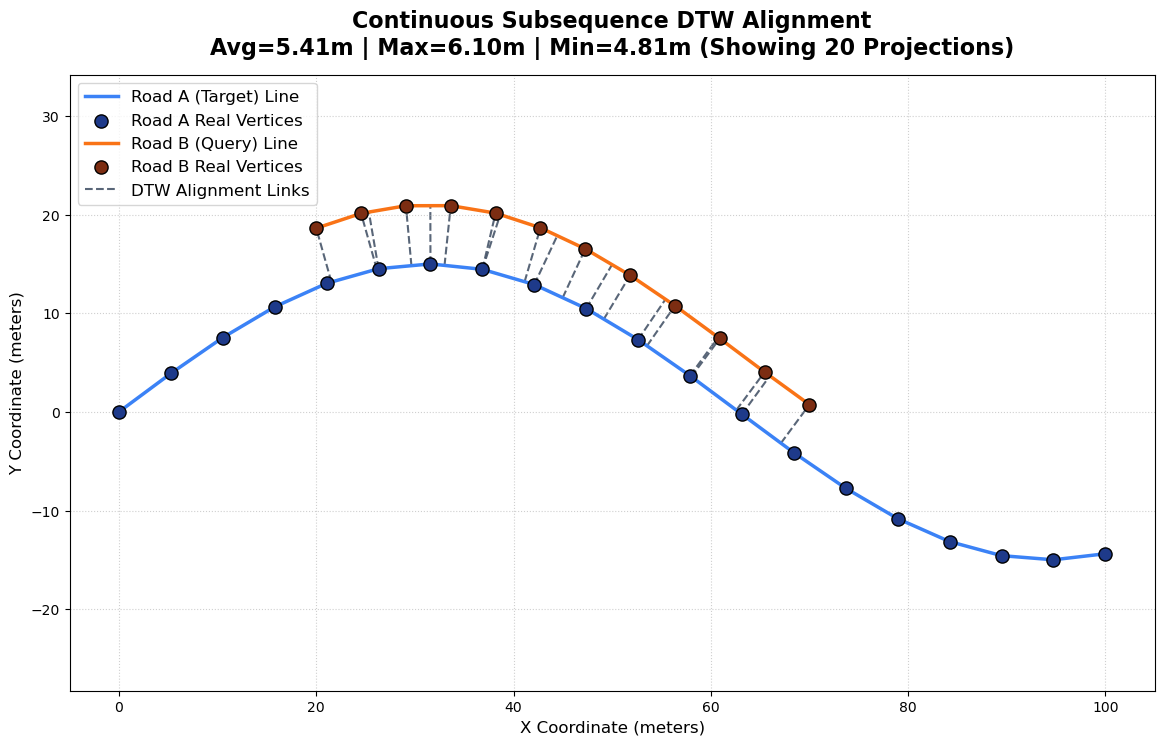

In [8]:
plt.figure(figsize=(14, 8))

# 1. Plot Road A (Target) Line and Real Vertices
real_a = np.array(coords_a)
plt.plot(real_a[:, 0], real_a[:, 1], color='#3b82f6', linewidth=2.5, label='Road A (Target) Line', zorder=2)
plt.scatter(real_a[:, 0], real_a[:, 1], color='#1e3a8a', s=90, edgecolors='black', label='Road A Real Vertices', zorder=4) # Dark Blue

# 2. Plot Road B (Query) Line and Real Vertices
real_b = np.array(coords_b)
plt.plot(real_b[:, 0], real_b[:, 1], color='#f97316', linewidth=2.5, label='Road B (Query) Line', zorder=2)
plt.scatter(real_b[:, 0], real_b[:, 1], color='#7c2d12', s=90, edgecolors='black', label='Road B Real Vertices', zorder=4) # Dark Orange

# 3. Draw the warping path alignment links directly from the coordinate pairs!
for k, (pt_a, pt_b) in enumerate(warping_path):
    label = "DTW Alignment Links" if k == 0 else ""
    plt.plot([pt_a[0], pt_b[0]], [pt_a[1], pt_b[1]], 
             color='#475569', linestyle='--', linewidth=1.5, alpha=0.9, label=label, zorder=1)

# 4. Add styling and labels
plt.title(f"Continuous Subsequence DTW Alignment\nAvg={dtw_dist:.2f}m | Max={dtw_metrics['max']:.2f}m | Min={dtw_metrics['min']:.2f}m (Showing {len(warping_path)} Projections)", 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("X Coordinate (meters)", fontsize=12)
plt.ylabel("Y Coordinate (meters)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper left')
plt.axis('equal')

# Show the plot
plt.show()